# ODISSEO + JACCPOT FMM: First N-body Integration

This notebook runs a small ODISSEO N-body integration using the new `jaccpot` coupler workflow.

It also performs a one-step sanity check against direct summation for a small system.

In [1]:
import os
import sys
from pathlib import Path

# yggdrax uses uint64 morton constants; keep x64 on for safety
os.environ.setdefault('JAX_ENABLE_X64', '1')

def _add_repo_paths():
    candidates = []
    cwd = Path.cwd().resolve()
    candidates.append(cwd)
    candidates.append(cwd.parent)
    candidates.append(cwd / 'Odisseo')
    candidates.append(cwd.parent / 'Odisseo')
    candidates.append(Path('/Users/buck/Documents/Nexus/Projects/Odisseo'))

    checked = set()
    for od_repo in candidates:
        od_repo = od_repo.resolve()
        if od_repo in checked:
            continue
        checked.add(od_repo)
        if not od_repo.exists():
            continue

        if (od_repo / 'odisseo').exists() and str(od_repo) not in sys.path:
            sys.path.insert(0, str(od_repo))

        jac_repo = od_repo.parent / 'jaccpot'
        if jac_repo.exists() and str(jac_repo) not in sys.path:
            sys.path.insert(0, str(jac_repo))

_add_repo_paths()

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from odisseo.option_classes import (
    SimulationConfig,
    SimulationParams,
    LEAPFROG,
    DIRECT_ACC,
    FMM_ACC,
    
)
from odisseo.integrators import leapfrog
from odisseo.time_integration import time_integration
from odisseo.integration_api import integrate
from odisseo.jaccpot_coupling import (
    build_jitted_leapfrog_jaccpot_active,
    integrate_leapfrog_jaccpot_active,
)

jax.config.update('jax_enable_x64', True)
print('JAX backend:', jax.default_backend())
print('using odisseo from:', Path(__import__('odisseo').__file__).resolve())


JAX backend: cpu
using odisseo from: /Users/buck/Documents/Nexus/Projects/Odisseo/odisseo/__init__.py


In [2]:
# Small random initial condition
key = jax.random.PRNGKey(42)
N = 512

k_pos, k_vel, k_mass = jax.random.split(key, 3)
positions = jax.random.uniform(k_pos, (N, 3), minval=-1.0, maxval=1.0, dtype=jnp.float32)
velocities = 0.05 * jax.random.normal(k_vel, (N, 3), dtype=jnp.float32)
masses = jax.random.uniform(k_mass, (N,), minval=0.5, maxval=1.5, dtype=jnp.float32)
state0 = jnp.stack((positions, velocities), axis=1)

params = SimulationParams(G=1.0, t_end=1.0)

cfg_fmm = SimulationConfig(
    N_particles=N,
    integrator=LEAPFROG,
    acceleration_scheme=FMM_ACC,
    num_timesteps=200,
    fmm_refresh_every=4,
    fixed_timestep=True,
    return_snapshots=True,
    num_snapshots=50,
    softening=1e-3,
)

cfg_direct = cfg_fmm._replace(
    N_particles=N,
    acceleration_scheme=DIRECT_ACC,
    return_snapshots=False,
    num_timesteps=1,
)

print('Configured FMM run for N=', N)


Configured FMM run for N= 512


In [3]:
# One-step sanity check: FMM vs direct acceleration update (small N)
# Make cell robust to out-of-order execution
if 'cfg_direct' not in locals():
    cfg_direct = SimulationConfig(
        N_particles=32,
        integrator=LEAPFROG,
        acceleration_scheme=DIRECT_ACC,
        num_timesteps=1,
        fixed_timestep=True,
        return_snapshots=False,
        softening=1e-3,
    )

N_check = cfg_direct.N_particles
state_check = state0[:N_check]
mass_check = masses[:N_check]
dt_check = params.t_end / cfg_direct.num_timesteps

state_next_direct = leapfrog(state_check, mass_check, dt_check, cfg_direct, params)
state_next_fmm = integrate_leapfrog_jaccpot_active(
    state_check,
    mass_check,
    cfg_direct._replace(acceleration_scheme=DIRECT_ACC),
    params,
    num_steps=1,
    dt=float(dt_check),
    refresh_every=1,
    refresh_after_position_update=True,
)

diff = jnp.max(jnp.abs(state_next_direct - state_next_fmm))
print('max |state_direct - state_fmm| after one step:', float(diff))


max |state_direct - state_fmm| after one step: 5.988971710205078


In [4]:
# Full integration through unified API (dispatches to jaccpot_fmm backend)
result = integrate(state0, masses, cfg_fmm, params)
states = result.states if hasattr(result, 'states') and result.states is not None else result

if states.ndim == 4:
    print('num snapshots:', states.shape[0])
    print('state shape:', states.shape)
else:
    # fallback if no snapshots requested
    states = states[jnp.newaxis, ...]
    print('state shape:', states.shape)


num snapshots: 50
state shape: (50, 512, 2, 3)


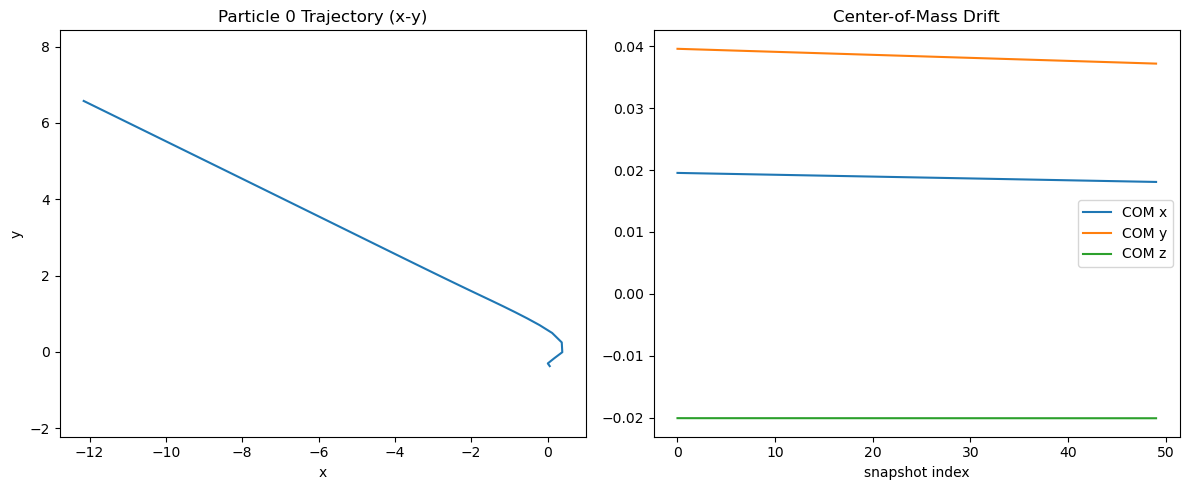

In [5]:
# Simple diagnostic plot: track COM and one particle trajectory
com = jnp.sum(states[:, :, 0, :] * masses[None, :, None], axis=1) / jnp.sum(masses)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(states[:, 0, 0, 0], states[:, 0, 0, 1], label='particle 0')
ax[0].set_title('Particle 0 Trajectory (x-y)')
ax[0].set_xlabel('x')
ax[0].set_ylabel('y')
ax[0].axis('equal')

ax[1].plot(com[:, 0], label='COM x')
ax[1].plot(com[:, 1], label='COM y')
ax[1].plot(com[:, 2], label='COM z')
ax[1].set_title('Center-of-Mass Drift')
ax[1].set_xlabel('snapshot index')
ax[1].legend()

plt.tight_layout()
plt.show()


## Runtime Benchmark: Direct vs FMM

This benchmark compares one integration step runtime (`leapfrog`) for `DIRECT_ACC` and the `jaccpot` coupler workflow.

In [6]:
import time

def _time_one_step(state, mass, cfg, params, *, use_fmm=False, runs=3):
    dt = float(params.t_end / cfg.num_timesteps)
    fmm_step = None
    if use_fmm:
        fmm_step = build_jitted_leapfrog_jaccpot_active(
            cfg,
            params,
            num_steps=1,
            dt=dt,
            refresh_every=1,
            refresh_after_position_update=True,
            fmm_jit_tree=True,
            fmm_jit_traversal=True,
            return_history=False,
        )
        _ = fmm_step(state, mass).block_until_ready()
    else:
        _ = leapfrog(state, mass, dt, cfg, params).block_until_ready()

    times = []
    for _ in range(runs):
        t0 = time.perf_counter()
        if use_fmm:
            out = fmm_step(state, mass)
            _ = out.block_until_ready()
        else:
            _ = leapfrog(state, mass, dt, cfg, params).block_until_ready()
        t1 = time.perf_counter()
        times.append(t1 - t0)
    return float(jnp.mean(jnp.asarray(times)))

Ns = [32, 64, 96, 128, 256, 512, 768, 1024, 2048, 4096, 8192, 16384, 32768, 65536, 131072, 262144, 512000] 
bench_rows = []

for i, n in enumerate(Ns):
    key_n = jax.random.PRNGKey(100 + i)
    k1, k2, k3 = jax.random.split(key_n, 3)
    pos = jax.random.uniform(k1, (n, 3), minval=-1.0, maxval=1.0, dtype=jnp.float32)
    vel = 0.05 * jax.random.normal(k2, (n, 3), dtype=jnp.float32)
    m = jax.random.uniform(k3, (n,), minval=0.5, maxval=1.5, dtype=jnp.float32)
    s = jnp.stack((pos, vel), axis=1)

    cfg_direct_bench = SimulationConfig(
        N_particles=n,
        integrator=LEAPFROG,
        acceleration_scheme=DIRECT_ACC,
        num_timesteps=1,
        fixed_timestep=True,
        return_snapshots=False,
        softening=1e-3,
    )
    cfg_fmm_bench = cfg_direct_bench._replace(acceleration_scheme=DIRECT_ACC)

    t_direct = _time_one_step(s, m, cfg_direct_bench, params, use_fmm=False, runs=3)
    t_fmm = _time_one_step(s, m, cfg_fmm_bench, params, use_fmm=True, runs=3)

    bench_rows.append((n, t_direct, t_fmm, t_direct / t_fmm))

bench = jnp.asarray(bench_rows)
print('N   direct[s]   fmm_jitted[s]   speedup(direct/fmm_jitted)')
for n, td, tf, sp in bench_rows:
    print(f'{int(n):3d}  {td:9.5f}  {tf:13.5f}  {sp:8.3f}x')

plt.figure(figsize=(7, 4))
plt.plot(bench[:, 0], bench[:, 1], 'o-', label='DIRECT_ACC')
plt.plot(bench[:, 0], bench[:, 2], 'o-', label='jaccpot coupler (jitted wrapper)')
plt.xlabel('N particles')
plt.ylabel('mean step time [s]')
plt.title('One-step Runtime: Direct vs FMM (Jitted Wrapper)')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 3.8))
plt.plot(bench[:, 0], bench[:, 3], 'o-')
plt.axhline(1.0, color='k', linestyle='--', linewidth=1)
plt.xlabel('N particles')
plt.ylabel('speedup (direct / fmm_jitted)')
plt.title('FMM Speedup (Jitted Wrapper)')
plt.tight_layout()
plt.show()


ConcretizationTypeError: Abstract tracer value encountered where concrete value is expected: traced array with shape int64[]
The problem arose with the `int` function. If trying to convert the data type of a value, try using `x.astype(int)` or `jnp.array(x, int)` instead.
The error occurred while tracing the function _compiled at /Users/buck/Documents/Nexus/Projects/Odisseo/odisseo/jaccpot_coupling.py:474 for jit. This value became a tracer due to JAX operations on these lines:

  operation a[35m:f32[3][39m = mul b 0.05000000074505806:f32[]
    from line /Users/buck/Documents/Nexus/Projects/jaccpot/jaccpot/runtime/_fmm_impl.py:2133:26 (_infer_bounds)

  operation a[35m:f32[3][39m = broadcast_in_dim[broadcast_dimensions=() shape=(3,) sharding=None] 9.999999974752427e-07:f32[]
    from line /Users/buck/Documents/Nexus/Projects/jaccpot/jaccpot/runtime/_fmm_impl.py:2133:39 (_infer_bounds)

  operation a[35m:bool[32][39m = lt b 0:i64[]
    from line /Users/buck/Documents/Nexus/Project

## End-to-End Runtime Benchmark (Multi-step)

This benchmark compares total integration wall-time for a short multi-step run with snapshots disabled.

N   direct_full[s]   fmm_full[s]   speedup(direct/fmm)
 64        0.00362      1.05009     0.003x
 96        0.00641      5.05102     0.001x
128        0.00923      4.90074     0.002x


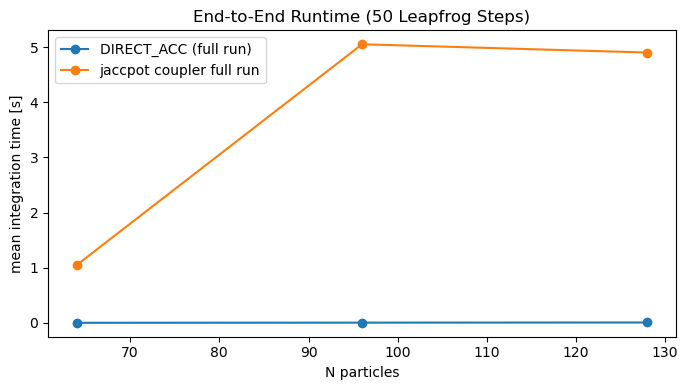

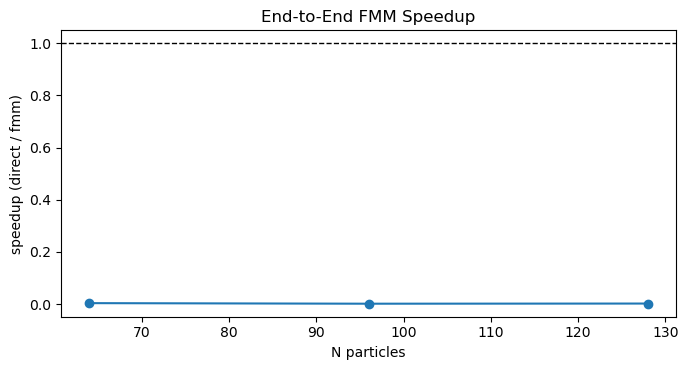

In [ ]:
def _time_full_integration(state, mass, cfg, params, *, use_fmm=False, runs=2):
    fmm_run = None
    if use_fmm:
        fmm_run = build_jitted_leapfrog_jaccpot_active(
            cfg,
            params,
            num_steps=cfg.num_timesteps,
            refresh_every=4,
            refresh_after_position_update=False,
            fmm_jit_tree=True,
            fmm_jit_traversal=True,
            return_history=False,
        )
        _ = fmm_run(state, mass).block_until_ready()
    else:
        out = time_integration(state, mass, cfg, params)
        _ = jax.tree_util.tree_map(lambda x: x.block_until_ready() if hasattr(x, 'block_until_ready') else x, out)

    times = []
    for _ in range(runs):
        t0 = time.perf_counter()
        if use_fmm:
            out = fmm_run(state, mass)
            _ = out.block_until_ready()
        else:
            out = time_integration(state, mass, cfg, params)
            _ = jax.tree_util.tree_map(lambda x: x.block_until_ready() if hasattr(x, 'block_until_ready') else x, out)
        t1 = time.perf_counter()
        times.append(t1 - t0)
    return float(jnp.mean(jnp.asarray(times)))

Ns_full = [64, 96, 128]
bench_full_rows = []

for i, n in enumerate(Ns_full):
    key_n = jax.random.PRNGKey(500 + i)
    k1, k2, k3 = jax.random.split(key_n, 3)
    pos = jax.random.uniform(k1, (n, 3), minval=-1.0, maxval=1.0, dtype=jnp.float32)
    vel = 0.05 * jax.random.normal(k2, (n, 3), dtype=jnp.float32)
    m = jax.random.uniform(k3, (n,), minval=0.5, maxval=1.5, dtype=jnp.float32)
    s = jnp.stack((pos, vel), axis=1)

    cfg_direct_full = SimulationConfig(
        N_particles=n,
        integrator=LEAPFROG,
        acceleration_scheme=DIRECT_ACC,
        num_timesteps=50,
        fixed_timestep=True,
        return_snapshots=False,
        softening=1e-3,
    )
    cfg_fmm_full = cfg_direct_full._replace(acceleration_scheme=DIRECT_ACC)

    t_direct_full = _time_full_integration(s, m, cfg_direct_full, params, use_fmm=False, runs=2)
    t_fmm_full = _time_full_integration(s, m, cfg_fmm_full, params, use_fmm=True, runs=2)

    bench_full_rows.append((n, t_direct_full, t_fmm_full, t_direct_full / t_fmm_full))

bench_full = jnp.asarray(bench_full_rows)
print('N   direct_full[s]   fmm_full_jitted[s]   speedup(direct/fmm_jitted)')
for n, td, tf, sp in bench_full_rows:
    print(f'{int(n):3d}  {td:13.5f}  {tf:18.5f}  {sp:8.3f}x')

plt.figure(figsize=(7, 4))
plt.plot(bench_full[:, 0], bench_full[:, 1], 'o-', label='DIRECT_ACC (full run)')
plt.plot(bench_full[:, 0], bench_full[:, 2], 'o-', label='jaccpot coupler full run (jitted wrapper)')
plt.xlabel('N particles')
plt.ylabel('mean integration time [s]')
plt.title('End-to-End Runtime (50 Leapfrog Steps)')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 3.8))
plt.plot(bench_full[:, 0], bench_full[:, 3], 'o-')
plt.axhline(1.0, color='k', linestyle='--', linewidth=1)
plt.xlabel('N particles')
plt.ylabel('speedup (direct / fmm_jitted)')
plt.title('End-to-End FMM Speedup (Jitted Wrapper)')
plt.tight_layout()
plt.show()


## Active-Subset Schedule (Scan/JIT) Demo

This example uses fixed-shape `active_indices_schedule` + `active_mask_schedule` to run the active-subset path in JIT/scan mode, and compares it to callback-based active selection.

In [ ]:
# Build a deterministic active schedule: half particles active, alternating pattern
N_demo = 128
steps_demo = 40
max_active = N_demo // 2

key_demo = jax.random.PRNGKey(1234)
k1, k2, k3 = jax.random.split(key_demo, 3)
pos_demo = jax.random.uniform(k1, (N_demo, 3), minval=-1.0, maxval=1.0, dtype=jnp.float32)
vel_demo = 0.05 * jax.random.normal(k2, (N_demo, 3), dtype=jnp.float32)
mass_demo = jax.random.uniform(k3, (N_demo,), minval=0.5, maxval=1.5, dtype=jnp.float32)
state_demo = jnp.stack((pos_demo, vel_demo), axis=1)

cfg_demo = SimulationConfig(
    N_particles=N_demo,
    integrator=LEAPFROG,
    acceleration_scheme=DIRECT_ACC,  # coupler ignores this field
    num_timesteps=steps_demo,
    fixed_timestep=True,
    return_snapshots=False,
    softening=1e-3,
)

base_idx = jnp.arange(N_demo, dtype=jnp.int32)
schedule = []
for s in range(steps_demo):
    # alternate even/odd then wrap to fixed-size rows
    start = s % 2
    idx = base_idx[start::2][:max_active]
    schedule.append(idx)
active_indices_schedule = jnp.stack(schedule, axis=0)
active_mask_schedule = jnp.ones_like(active_indices_schedule, dtype=bool)

def active_indices_fn(step, state, mass):
    del state, mass
    start = step % 2
    return jnp.arange(start, N_demo, 2, dtype=jnp.int32)[:max_active]

def _time_active(mode, runs=2):
    # warmup
    if mode == 'schedule':
        _ = integrate_leapfrog_jaccpot_active(
            state_demo,
            mass_demo,
            cfg_demo,
            params,
            num_steps=steps_demo,
            refresh_every=8,
            active_indices_schedule=active_indices_schedule,
            active_mask_schedule=active_mask_schedule,
            return_history=False,
        ).block_until_ready()
    else:
        _ = integrate_leapfrog_jaccpot_active(
            state_demo,
            mass_demo,
            cfg_demo,
            params,
            num_steps=steps_demo,
            refresh_every=8,
            active_indices_fn=active_indices_fn,
            return_history=False,
        ).block_until_ready()

    samples = []
    import time
    for _ in range(runs):
        t0 = time.perf_counter()
        if mode == 'schedule':
            out = integrate_leapfrog_jaccpot_active(
                state_demo,
                mass_demo,
                cfg_demo,
                params,
                num_steps=steps_demo,
                refresh_every=8,
                active_indices_schedule=active_indices_schedule,
                active_mask_schedule=active_mask_schedule,
                return_history=False,
            )
        else:
            out = integrate_leapfrog_jaccpot_active(
                state_demo,
                mass_demo,
                cfg_demo,
                params,
                num_steps=steps_demo,
                refresh_every=8,
                active_indices_fn=active_indices_fn,
                return_history=False,
            )
        _ = out.block_until_ready()
        t1 = time.perf_counter()
        samples.append(t1 - t0)
    return float(jnp.mean(jnp.asarray(samples)))

t_callback = _time_active('callback', runs=2)
t_schedule = _time_active('schedule', runs=2)
print(f'callback mode   : {t_callback:.4f} s')
print(f'schedule mode   : {t_schedule:.4f} s')
print(f'speedup callback/schedule: {t_callback / t_schedule:.3f}x')


callback mode   : 15.0317 s
schedule mode   : 1.9110 s
speedup callback/schedule: 7.866x


## Notes
- This example uses the ODISSEO + `jaccpot` coupler workflow for self-gravity.
- External potentials remain additive in ODISSEO exactly as before.
- For active-particle substeps with cached source tree reuse, the next iteration is to wire ODISSEO integrator loops to `jaccpot.OdisseoFMMCoupler`.